# Continuación de electromagnetismo
Problema: Una región cuadrada de NxN con N = 50 posee una densidad de carga:
- Borde superior $V_0 = 500$
- Resto de bordes $V = 0$
- Densidad de carga en una región cargada pequeña $\rho = 50$


In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [40]:
Nx = 50
Ny = 50

h = 1
tol = 1e-4
max_iterations = int(10000)
V01 = 100
V02 = 0
rho0 = 50

u = np.zeros((Nx, Ny))
#Extremo superior
u[:,Ny - 1] = V01
#Extremos laterales e inferior
u[0, 1:] = V02
u[Nx - 1, 1:] = V02
u[1:-2, 0]  = V02
rho = np.zeros((Nx, Ny))
rho[20:30,20:30] = rho0

#Gauss-Scheffel
for iteration in range(max_iterations):
    uold = u.copy()
    for i in range(1, Nx - 1):
        for j in range(1, Ny - 1):
            u[i, j] = (u[i + 1, j] + u[i - 1, j] + u[i, j + 1] + u[i, j - 1] +  rho[i, j] * h ** 2) / 4
    
        error = np.max(np.abs(u - uold))
    if iteration % 100 == 0:
        print('Iteración: ', iteration, 'Error: ', error)

    if error < tol: 
        print('Tolerancia alcanzada')
        break

Iteración:  0 Error:  33.333333352903885
Iteración:  100 Error:  3.7017731709730697
Iteración:  200 Error:  1.9497102971370168
Iteración:  300 Error:  1.235953458282438
Iteración:  400 Error:  0.8124828035026894
Iteración:  500 Error:  0.5377239846359316
Iteración:  600 Error:  0.3563167089664603
Iteración:  700 Error:  0.2361551248361593
Iteración:  800 Error:  0.1565183252632778
Iteración:  900 Error:  0.10373590761469131
Iteración:  1000 Error:  0.06875265766007033
Iteración:  1100 Error:  0.04556671135446777
Iteración:  1200 Error:  0.03019984055254099
Iteración:  1300 Error:  0.020015246375351126
Iteración:  1400 Error:  0.01326529356424544
Iteración:  1500 Error:  0.008791694595856825
Iteración:  1600 Error:  0.005826774548950198
Iteración:  1700 Error:  0.0038617466505002085
Iteración:  1800 Error:  0.0025594067528800224
Iteración:  1900 Error:  0.0016962694000994816
Iteración:  2000 Error:  0.001124217483038592
Iteración:  2100 Error:  0.0007450850296208955
Iteración:  2200 Err

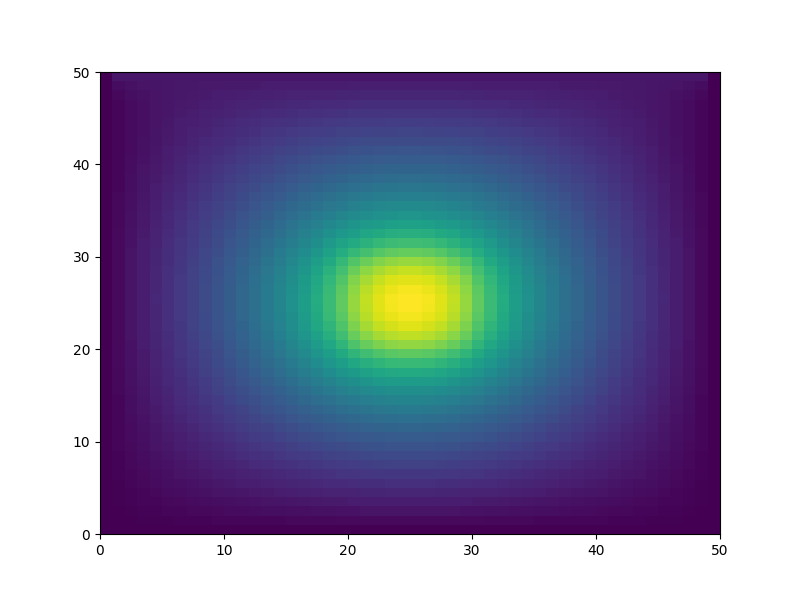

In [41]:
#malla
x = np.arange(0, Nx) 
y = np.arange(0, Ny) 

X, Y = np.meshgrid(x, y)
plt.figure(figsize=(8,6))
plt.imshow(
            u.T,
            origin = 'lower',
            extent = [0, Nx * h, 0, Ny * h],
            aspect = 'auto'
)
plt.show()

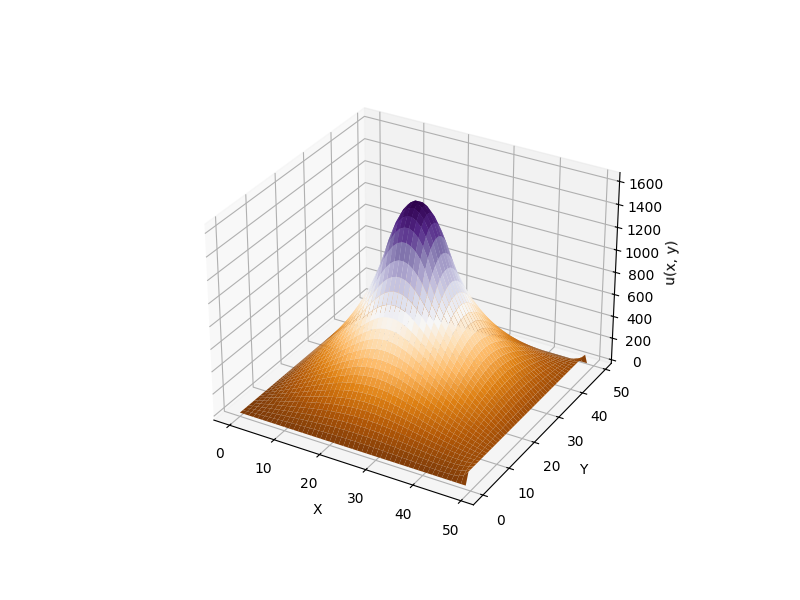

In [43]:
from mpl_toolkits.mplot3d import Axes3D
%matplotlib widget

fig = plt.figure(figsize = (8, 6))
ax = fig.add_subplot(111, projection = '3d')
ax.plot_surface(X, Y, u, cmap = 'PuOr')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('u(x, y)')

plt.show()

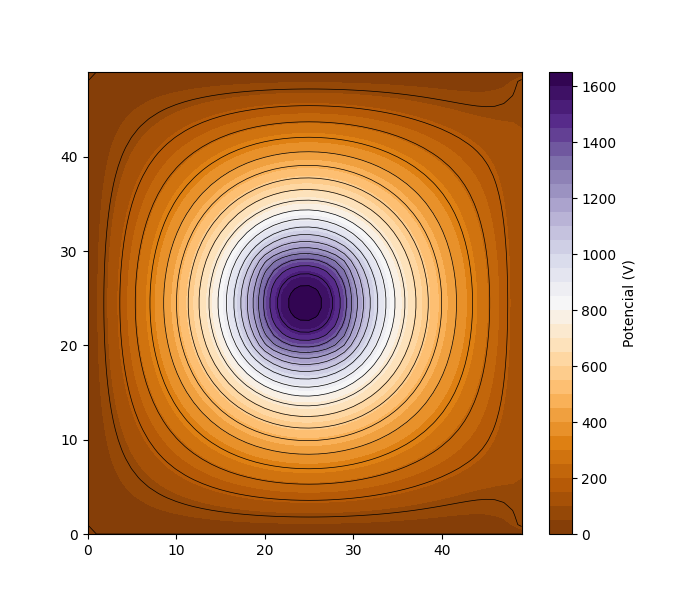

In [44]:
plt.figure(figsize=(7,6))

cont = plt.contourf(X, Y, u,
                    40, 
                    cmap = 'PuOr')
plt.colorbar(label='Potencial (V)')
plt.contour(X, Y, u,
            20, 
            colors = 'black',
            linewidths = 0.5)
plt.show()

# Componentes del campo magnético:
El campo magnético se calcula:
$$E_{x_i} = \frac{\partial V}{\partial x_i}$$
$$E_x = \frac{V_{i+1, j}-V{i-1,j}}{\Delta x}$$

In [56]:
E_x = np.zeros((Nx, Ny))
E_y = np.zeros((Nx, Ny))
h = 1

for i in range(1, Nx - 1):
    for j in range(1, Ny - 1):
        E_x[i, j] = - (u[i + 1, j] - u[i - 1, j]) / (2 * h)
        E_y[i, j] = - (u[i, j + 1] - u[i, j - 1]) / ( 2 * h)

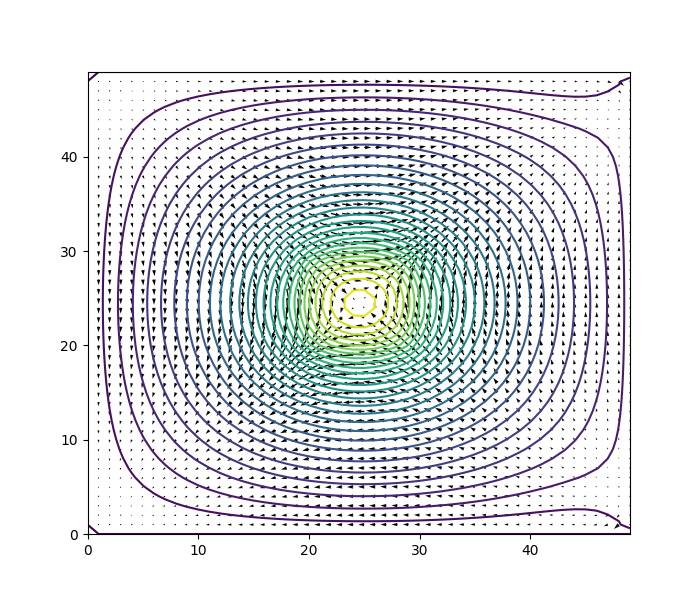

In [62]:
plt.figure(figsize=(7,6))


plt.quiver(X, Y, E_x, E_y)
plt.contour(X, Y, u, levels = 30)

# Problema 2
Carga puntual q colocada dentro de un cilindro conductor de radio a y longitud L.
- Las paredesdes y las tapas del cilindro se encuentran a $V = 0$
- $V(\rho = a, \phi, z) = 0$
- $V(\rho, \phi, 0)$ = 0 = $V(\rho, \phi, L)$

La carga se encuentra ubicada en $(\rho_0,\phi_0,z_0)$

In [ ]:
from scipy.special import jn, jn_zeros
epsilon0 = 8.85e-12
q = 1
a = 20
L = 20

#Posición de la carga
rho0 = 12
phi0 = np.pi / 4
z0 = 15.0

#parámetros numéricos
Nm = 8 #modos angulares
Nn = 12 #ceros de bessel

Nrho = 60 #puntos radiales
Nphi = 80 #puntos angulares

#función potencial
def potencial(rho, phi, z):
    suma_total = np.zeros_like(rho, dtype=np.float64)

    #suma sobre m
    for m  in range(-Nm, Nm + 1):
        #orden absoluto para funciones de bessel
        mabs = abs(m)

        #ceros de Bessel J_m
        zeros = jn_zeros(mabs, Nn)
        for n in range(Nn):
            xmn = zeros[n]
            J1 = jn(mabs, xmn * rho / a)
            J2 = jn(mabs, xmn * rho0 / a)
            
    return suma_total


In [4]:
epsilon0 = 8.854e-12
a = 20
L = 20

Nr = 80
Nz = 80

dr = a / (Nr - 1)
dz = L / (Nz - 1)

rho = np.linspace(0, a, Nr)
z = np.linspace(0, L, Nz)

R, Z = np.meshgrid(rho, z)

V = np.zeros((Nr, Nz))

rho_charge = np.zeros_like(V)

q = 1e-9

rho0 = 8.0
z0 = 10.0

ir = int(rho0 / dr)
iz = int(z0 / dz)

#aproximación discreta del delta de Dirac
rho_charge[iz, ir] = q / (dr * dz)

max_iterations = 5000
tolerance = 1e-5

print('Iterando')
#método gauss

for iteration in range(max_iterations):
    Vold = V.copy()
    for i in range(1, Nz - 1):
        for j in range(1, Nr - 1):
            rj = rho[j]

            #término radial cilíndrico
            term_r = (
                (1 + dr / (2 * rj) * V[i, j + 1])
                +
                (1 - dr / (2 * rj)) * V[i, j - 1]
            ) / dr ** 2

            #término axial
            term_z = (
                V[i + 1, j]
                +
                V[i - 1, j]
            ) / dz ** 2

            #Denominador
            denom = 2 / dr ** 2 + 2 / dr ** 2

            #Actualización GAus engels
            V[i, j] = (
                term_r
                +
                term_z
                +
                rho_charge[i, j] / epsilon0
            ) / denom
    #Condición especial en rho = 0
    #simetría axial: par V / par rho = 0
    V[:, 0] = V[:, 1]
    #error máximo
    error = np.max(np.abs(V-Vold))
    if iteration % 100 == 0:
        print('Iteration: ', iteration,'Error: ', error)
    if error < tolerance:
        print('Convergencia alcanzada')
        break


Iterando
Iteration:  0 Error:  28.731758844749255
Convergencia alcanzada
